# Uncertainty Modeling of Hover Time 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import lognorm

In [2]:
def get_shifted_lognormal_params(target_mean, target_std, shift):
    """Calculates lognormal parameters (s, scale) for a shifted distribution."""
    mu_prime = target_mean - shift
    v_prime = target_std**2
    s_sq = np.log(v_prime / mu_prime**2 + 1)
    s = np.sqrt(s_sq)
    scale = mu_prime / np.sqrt(v_prime / mu_prime**2 + 1)
    return s, scale, shift

In [3]:
# --- CONFIGURATION (Johannes' Research Parameters) ---
T_MEAN = 55.0    
T_STD = 18.0     
T_MIN = 25.0     

s, scale, loc = get_shifted_lognormal_params(T_MEAN, T_STD, T_MIN)
dist = lognorm(s, loc=loc, scale=scale)

In [4]:
# --- EXACT PERCENTILE BOUNDS (alpha=0.05) ---
p_lower = 0.025
p_upper = 0.975
bound_lower = dist.ppf(p_lower)
bound_upper = dist.ppf(p_upper)

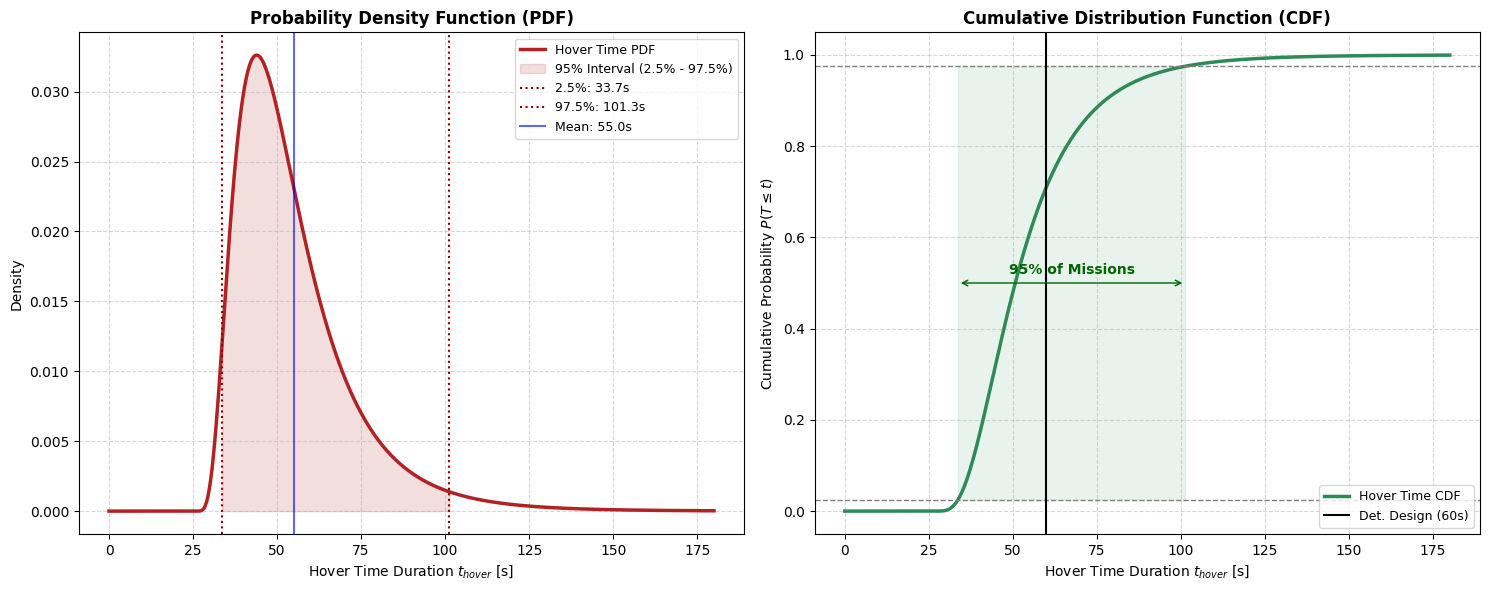

In [5]:
# --- PLOTTING ---
x = np.linspace(0, 180, 1000)
pdf = dist.pdf(x)
cdf = dist.cdf(x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 1. PDF PLOT: 2.5% to 97.5% Range
ax1.plot(x, pdf, color='firebrick', lw=2.5, label='Hover Time PDF')
ax1.fill_between(x, pdf, where=(x >= bound_lower) & (x <= bound_upper), 
                 color='firebrick', alpha=0.15, label='95% Interval (2.5% - 97.5%)')

# Vertical lines for bounds
ax1.axvline(bound_lower, color='darkred', ls=':', lw=1.5, label=f'2.5%: {bound_lower:.1f}s')
ax1.axvline(bound_upper, color='darkred', ls=':', lw=1.5, label=f'97.5%: {bound_upper:.1f}s')
ax1.axvline(T_MEAN, color='blue', ls='-', alpha=0.6, label=f'Mean: {T_MEAN}s')

ax1.set_title('Probability Density Function (PDF)', fontweight='bold')
ax1.set_xlabel('Hover Time Duration $t_{hover}$ [s]')
ax1.set_ylabel('Density')
ax1.legend(fontsize=9)
ax1.grid(True, which='both', linestyle='--', alpha=0.5)

# 2. CDF PLOT: Visualizing the "Tails"
ax2.plot(x, cdf, color='seagreen', lw=2.5, label='Hover Time CDF')

# Shade the 95% probability mass on the CDF
ax2.fill_betweenx([p_lower, p_upper], bound_lower, bound_upper, color='seagreen', alpha=0.1)

# Highlight specific probability thresholds
ax2.axhline(p_lower, color='grey', ls='--', lw=1)
ax2.axhline(p_upper, color='grey', ls='--', lw=1)
ax2.axvline(60, color='black', ls='-', lw=1.5, label='Det. Design (60s)')

# Annotate the interval on the CDF
ax2.annotate('', xy=(bound_lower, 0.5), xytext=(bound_upper, 0.5),
             arrowprops=dict(arrowstyle='<->', color='darkgreen'))
ax2.text((bound_lower+bound_upper)/2, 0.52, '95% of Missions', 
         ha='center', color='darkgreen', fontweight='bold')

ax2.set_title('Cumulative Distribution Function (CDF)', fontweight='bold')
ax2.set_xlabel('Hover Time Duration $t_{hover}$ [s]')
ax2.set_ylabel('Cumulative Probability $P(T \leq t)$')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

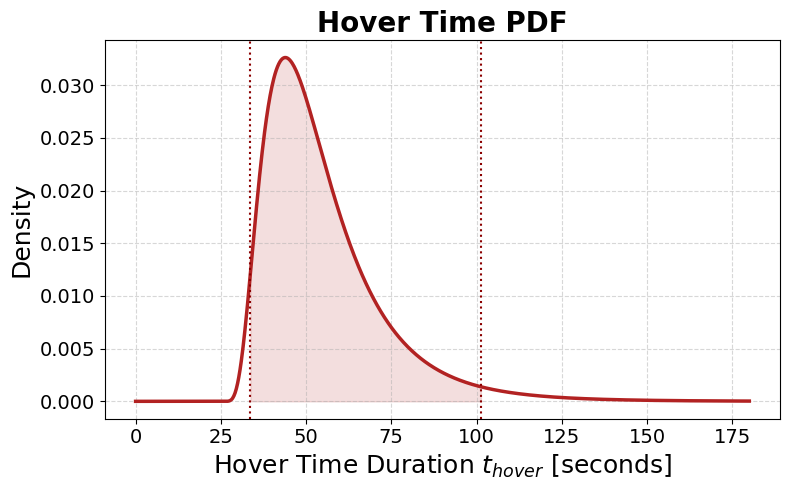

--- Uncertainty Characterization for RMDO ---
Lower Bound (2.5th percentile): 33.677 s
Upper Bound (97.5th percentile): 101.270 s
Total Width of 95% Interval: 67.593 s
Probability mission exceeds 60s: 28.94%


In [6]:
# --- ADDITIONAL CLEAN PDF PLOT ---
fig_clean, ax_clean = plt.subplots(figsize=(8, 5))

# PDF curve
ax_clean.plot(x, pdf, color='firebrick', lw=2.5)

# 95% interval shading
ax_clean.fill_between(
    x,
    pdf,
    where=(x >= bound_lower) & (x <= bound_upper),
    color='firebrick',
    alpha=0.15
)

# Percentile bounds only
ax_clean.axvline(bound_lower, color='darkred', ls=':', lw=1.5)
ax_clean.axvline(bound_upper, color='darkred', ls=':', lw=1.5)

# Labels and styling
ax_clean.set_title('Hover Time PDF', fontweight='bold', fontsize=20)
ax_clean.set_xlabel('Hover Time Duration $t_{hover}$ [seconds]', fontsize=18)
ax_clean.set_ylabel('Density', fontsize=18)
ax_clean.tick_params(axis='both', labelsize=14)

ax_clean.grid(True, which='both', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Print statements for your .pptx Documentation
print(f"--- Uncertainty Characterization for RMDO ---")
print(f"Lower Bound (2.5th percentile): {bound_lower:.3f} s")
print(f"Upper Bound (97.5th percentile): {bound_upper:.3f} s")
print(f"Total Width of 95% Interval: {bound_upper - bound_lower:.3f} s")
print(f"Probability mission exceeds 60s: {(1 - dist.cdf(60))*100:.2f}%")